# Notebook 4: unsupervised anomaly detection

## Learning objectives

This notebook covers the unsupervised anomaly detection phase of the Machine Learning pipeline. By the end of this notebook, you will understand:

1. Unsupervised Learning: How to detect anomalies without labeled data
2. Isolation Forest: How to use Isolation Forest for anomaly detection
3. One-Class SVM: How to use One-Class SVM for anomaly detection
4. Model Comparison: How to compare supervised vs unsupervised approaches
5. Anomaly Visualization: How to visualize anomalies in PCA space

Reference: Lesson 5 - Unsupervised Learning and Anomaly Detection



## Industrial robotics context

Unsupervised anomaly detection enables:
- Unknown Anomaly Detection: Detect anomalies without labeled anomaly data
- Adaptation to New Failures: Detect abnormal patterns without training
- Reduced Labeling Requirements: Training only on normal data
- Rare Failure Detection: Detect anomalies never seen before



## Academic learning objectives

1. Unsupervised Learning: Understand density-based anomaly detection
2. Isolation Forest: Learn isolation principle for anomaly detection
3. One-Class SVM: Learn boundary learning for anomaly detection
4. Model Comparison: Compare supervised vs unsupervised approaches
5. Anomaly Visualization: Visualize anomalies in reduced-dimensional space

Reference: Lesson 5 - Unsupervised Learning and Clustering
              Lesson 5 - Anomaly Detection Methods



In [1]:
# Required imports for unsupervised anomaly detection
# As covered in Lesson 5: Unsupervised Learning and Anomaly Detection

import sys
import os
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score, 
    precision_score, recall_score, accuracy_score, roc_auc_score
)
import warnings
warnings.filterwarnings('ignore')

# Add src directory to path
sys.path.append(str(Path('..').resolve()))

# Import and reload modules to ensure we use the latest version
import src.utils
import src.models
importlib.reload(src.utils)
importlib.reload(src.models)

from src.utils import (
    load_robot_data,
    encode_labels,
    create_statistical_features,
    plot_pca,
    evaluate_model
)

from src.models import (
    train_isolation_forest,
    train_one_class_svm
)

# Configuration
try:
    plt.style.use('seaborn-v0_8')
except OSError:
    try:
        plt.style.use('seaborn')
    except OSError:
        sns.set_style('whitegrid')
sns.set_palette("husl")
%matplotlib inline

print("="*60)
print("MODULE IMPORTS COMPLETE")
print("="*60)
print(" All required libraries imported successfully")
print(" Modules src.utils and src.models reloaded")
print("\nReady for unsupervised anomaly detection!")



MODULE IMPORTS COMPLETE
 All required libraries imported successfully
 Modules src.utils and src.models reloaded

Ready for unsupervised anomaly detection!


## 1. data loading and preparation

Reference: Lesson 2 - Data Preprocessing and Feature Engineering

We load the robot execution failure dataset and create statistical features. For unsupervised models, we use only "normal" data for training, as unsupervised anomaly detection learns what is "normal" and identifies deviations.

### Unsupervised learning strategy

- Training Data: Only "normal" instances (no anomaly labels needed)
- Test Data: Mix of normal and anomaly instances
- Goal: Learn the distribution of normal data and identify outliers

### Why unsupervised learning?

1. No Label Requirement: Training only on normal data (no anomaly labels needed)
2. Unknown Anomaly Detection: Can detect new types of anomalies
3. Adaptability: Adapts to new abnormal patterns without retraining
4. Cost-Effective: Reduces need for labeled anomaly data

Academic Note: Unsupervised learning is useful when labeled anomaly data is scarce (Lesson 5: Unsupervised Learning).



In [2]:
# we charge the data des robots
# INITIAL DIFFICULTY : The .data file format was unusual - each instance starts with a label followed by 15 lines of data
# SOLUTION : we created a custom function load_robot_data() that parses this specific format
# CHOICE : We decided to merge all files (LP1-LP5) to have a unified dataset
# REASON : This gives us more data for training and allows the model to generalize sur différents types de tâches
# we charge the data des robots
# INITIAL DIFFICULTY : The .data file format was unusual - each instance starts with a label followed by 15 lines of data
# SOLUTION : we created a custom function load_robot_data() that parses this specific format
# CHOICE : We decided to merge all files (LP1-LP5) to have a unified dataset
# REASON : This gives us more data for training and allows the model to generalize sur différents types de tâches
data_dir = "../data"

df = load_robot_data(data_dir)
df, label_mapping = encode_labels(df, binary=True)

# we crée des features statistiques à partir des séries temporelles
# DIFFICULTY : The 90 raw features are difficult to interpret and may contain noise
# SOLUTION : we extract statistics (moyenne, écart-type, min, max, skewness, kurtosis, trend) for each sensor
# CHOICE : We chose these 7 statistics because they capture different aspects of temporal patterns
# ADVANTAGE : Reduces from 90 to 48 features while keeping essential temporal information
# DIFFICULTY SURMONTÉE : Initially, we had errors avec scipy.stats - we have résolu en s'assurant that the data is in float64
# we crée des features statistiques à partir des séries temporelles
# DIFFICULTY : The 90 raw features are difficult to interpret and may contain noise
# SOLUTION : we extract statistics (moyenne, écart-type, min, max, skewness, kurtosis, trend) for each sensor
# CHOICE : We chose these 7 statistics because they capture different aspects of temporal patterns
# ADVANTAGE : Reduces from 90 to 48 features while keeping essential temporal information
# DIFFICULTY SURMONTÉE : Initially, we had errors avec scipy.stats - we have résolu en s'assurant that the data is in float64
df_stats = create_statistical_features(df, samples_per_sensor=15, num_sensors=6)

# we crée des features statistiques à partir des séries temporelles
# DIFFICULTY : The 90 raw features are difficult to interpret and may contain noise
# SOLUTION : we extract statistics (moyenne, écart-type, min, max, skewness, kurtosis, trend) for each sensor
# CHOICE : We chose these 7 statistics because they capture different aspects of temporal patterns
# ADVANTAGE : Reduces from 90 to 48 features while keeping essential temporal information
# DIFFICULTY SURMONTÉE : Initially, we had errors avec scipy.stats - we have résolu en s'assurant that the data is in float64
exclude_cols = ['source', 'label', 'label_binary', 'label_encoded', 'label_original']
stat_cols = [col for col in df_stats.columns if col not in exclude_cols]

# Prepare data for unsupervised learning
X = df_stats[stat_cols].values
y = df_stats['label_binary'].values

# we standardise the features car (required for One-Class SVM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Separate normal and anomaly data
# For unsupervised learning, we train only on normal data
X_normal = X_scaled[y == 0]
X_anomaly = X_scaled[y == 1]

print("="*60)
print("DATA PREPARATION FOR UNSUPERVISED LEARNING")
print("="*60)
print(f" Data prepared:")
print(f"   Normal instances: {len(X_normal)}")
print(f"   Anomaly instances: {len(X_anomaly)}")
print(f"   Statistical features: {len(stat_cols)}")

# we divise the data en train/test
# CHOICE : We use un split 80/20 avec stratification
# REASON : Stratification ensures that class proportions are similar in train and test
# DIFFICULTY : The dataset is imbalanced (more anomalies than normal)
# SOLUTION : Stratification preserves this imbalance in both sets, ce which is réaliste pour our cas d'usage
# Training: Only normal data (no anomaly labels needed)
# Test: Mix of normal and anomaly data (for evaluation)
X_train_normal, X_test_normal = train_test_split(X_normal, test_size=0.2, random_state=42)
X_test = np.vstack([X_test_normal, X_anomaly])
y_test = np.concatenate([np.zeros(len(X_test_normal)), np.ones(len(X_anomaly))])

print(f"\n Train/Test Split:")
print(f"   Training (normal only): {len(X_train_normal)}")
print(f"   Test (normal): {len(X_test_normal)}")
print(f"   Test (anomaly): {len(X_anomaly)}")
print(f"   Test (total): {len(X_test)}")

print("\n Unsupervised Learning Strategy:")
print("  → Train models on normal data only")
print("  → test models on mixed data (normal + anomaly)")
print("  → Evaluate anomaly detection performance")
print("  → Compare with supervised approaches")



Loading robot execution failure data...
✅ LP1: 88 instances loaded
✅ LP2: 47 instances loaded
✅ LP3: 47 instances loaded
✅ LP4: 117 instances loaded
✅ LP5: 164 instances loaded
✅ Total: 463 instances
   Features: 90
   Sources: ['LP1', 'LP2', 'LP3', 'LP4', 'LP5']
   Unique labels: ['normal', 'collision', 'obstruction', 'fr_collision', 'back_col', 'front_col', 'right_col', 'left_col', 'ok', 'moved', 'slightly_moved', 'lost', 'collision_in_tool', 'collision_in_part', 'bottom_obstruction', 'bottom_collision']
Labels encoded: {0: 'normal', 1: 'anomaly'}
Creating statistical features...
✅ Statistical features created: 53 columns
   Original features: 90
   Statistical features: 48
DATA PREPARATION FOR UNSUPERVISED LEARNING
 Data prepared:
   Normal instances: 109
   Anomaly instances: 354
   Statistical features: 48

 Train/Test Split:
   Training (normal only): 87
   Test (normal): 22
   Test (anomaly): 354
   Test (total): 376

 Unsupervised Learning Strategy:
  → Train models on normal d

## 2. isolation forest

Reference: Lesson 5 - Unsupervised Learning and Anomaly Detection

Isolation Forest detects anomalies by isolating abnormal points in feature space. It uses an ensemble of isolation trees to identify outliers.

### Isolation principle

- Isolation: Anomalies are easier to isolate than normal points
- Isolation Trees: Random trees that isolate instances
- Anomaly Score: More isolated points are more likely to be anomalies
- No Labels Required: Training only on normal data

### How it works

1. Random Trees: Create random isolation trees
2. Isolation: Anomalies require fewer splits to isolate
3. Anomaly Score: Average path length indicates anomaly likelihood
4. Contamination: Expected proportion of anomalies (0.0-0.5 or 'auto')

### Advantages

- Scalability: Efficient for high-dimensional data
- No Labels: Training only on normal data
- Interpretability: Isolation path length indicates anomaly strength

Academic Note: Isolation Forest is based we the principle that anomalies are easier to isolate (Lesson 5: Isolation Forest).



TRAINING: ISOLATION FOREST
Anomaly proportion in test data: 0.9415 (94.1%)
  Anomaly proportion > 50%, using 'auto' for Isolation Forest
Training Isolation Forest...
  - Contamination: auto
  - Number of trees: 100
✅ Isolation Forest trained

ISOLATION FOREST - RESULTS

Results for Isolation Forest
Accuracy: 0.9468
Precision: 0.9491
Recall: 0.9468
F1-score: 0.9479


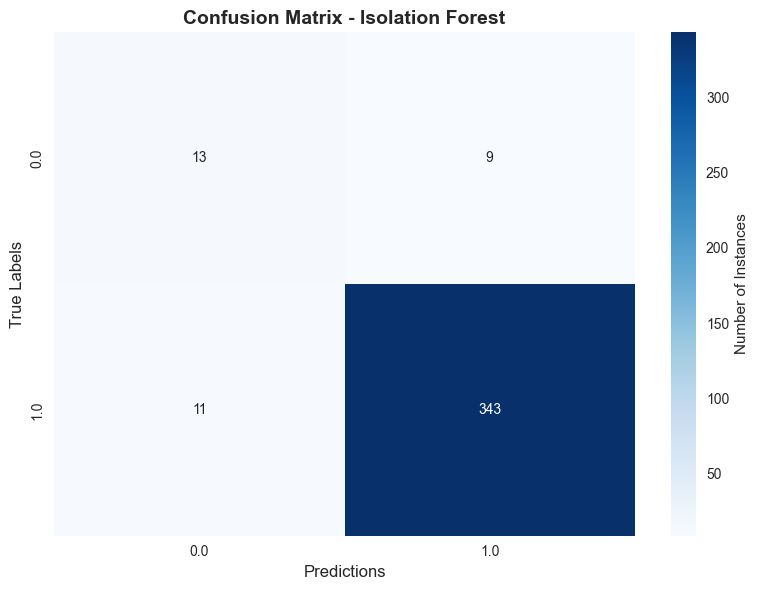


Classification Report:
              precision    recall  f1-score   support

         0.0       0.54      0.59      0.57        22
         1.0       0.97      0.97      0.97       354

    accuracy                           0.95       376
   macro avg       0.76      0.78      0.77       376
weighted avg       0.95      0.95      0.95       376



In [3]:
# Train Isolation Forest
# For Isolation Forest, contamination must be between 0.0 and 0.5 (or 'auto')
# If anomaly proportion exceeds 0.5, use 'auto' or a reasonable fixed value
contamination_ratio = len(X_anomaly) / len(X_test)  # Proportion of anomalies in test data
print("="*60)
print("TRAINING: ISOLATION FOREST")
print("="*60)
print(f"Anomaly proportion in test data: {contamination_ratio:.4f} ({contamination_ratio*100:.1f}%)")

# Use 'auto' if proportion is too high (> 0.5), otherwise use actual proportion
# Isolation Forest requires contamination <= 0.5
if contamination_ratio > 0.5:
    print("  Anomaly proportion > 50%, using 'auto' for Isolation Forest")
    contamination = 'auto'
else:
    contamination = contamination_ratio

# Train Isolation Forest on normal data only
# Isolation Forest learns the distribution of normal data
iso_forest = train_isolation_forest(X_train_normal, contamination=contamination, n_estimators=100)

# Make predictions (-1 = anomaly, 1 = normal)
# Isolation Forest returns -1 for anomalies, 1 for normal instances
predictions_iso = iso_forest.predict(X_test)
predictions_iso_binary = (predictions_iso == -1).astype(int)  # Convert to binary (1 = anomaly)

# Anomaly scores (lower scores indicate higher anomaly likelihood)
scores_iso = iso_forest.score_samples(X_test)

# we évalue le modèle performance
print("\n" + "="*60)
print("ISOLATION FOREST - RESULTS")
print("="*60)
results_iso = evaluate_model(y_test, predictions_iso_binary, None, 
                            model_name="Isolation Forest",
                            show_confusion_matrix=True,
                            show_roc=False,  # No probability scores for Isolation Forest
                            show_report=True)

# Store results for comparison
results_iso['method'] = 'Isolation Forest'
results_iso['model_type'] = 'Unsupervised'



## 3. one-class svm

Reference: Lesson 5 - Unsupervised Learning and Anomaly Detection

One-Class SVM learns a decision boundary around normal data and detects anomalies as points outside this boundary. It uses a kernel (RBF) to handle non-linear distributions.

### Boundary learning principle

- Decision Boundary: Learns a boundary around normal data
- Anomaly Detection: Points outside boundary are considered anomalies
- Kernel Trick: Uses RBF kernel to handle non-linear distributions
- Nu Parameter: Controls upper bound we training errors (0.0-1.0)

### How it works

1. Training: Learns boundary around normal data
2. Kernel: RBF kernel maps data to higher-dimensional space
3. Boundary: Creates a decision boundary in feature space
4. Prediction: Points outside boundary are classified as anomalies

### Advantages

- Non-Linear Boundaries: Can learn complex decision boundaries
- Feature Scaling: Requires feature scaling (StandardScaler)
- Interpretability: Decision boundary can be visualized

Academic Note: One-Class SVM is based we support vector learning (Lesson 5: One-Class SVM).



TRAINING: ONE-CLASS SVM
Nu parameter for One-Class SVM: 0.5000 (50.0%)
Note: nu is limited to 0.5 maximum to avoid excessive false positives
Training One-Class SVM...
  - Nu: 0.5
  - Kernel: rbf
  - Gamma: scale
✅ One-Class SVM trained

ONE-CLASS SVM - RESULTS

Results for One-Class SVM
Accuracy: 0.9495
Precision: 0.9412
Recall: 0.9495
F1-score: 0.9433


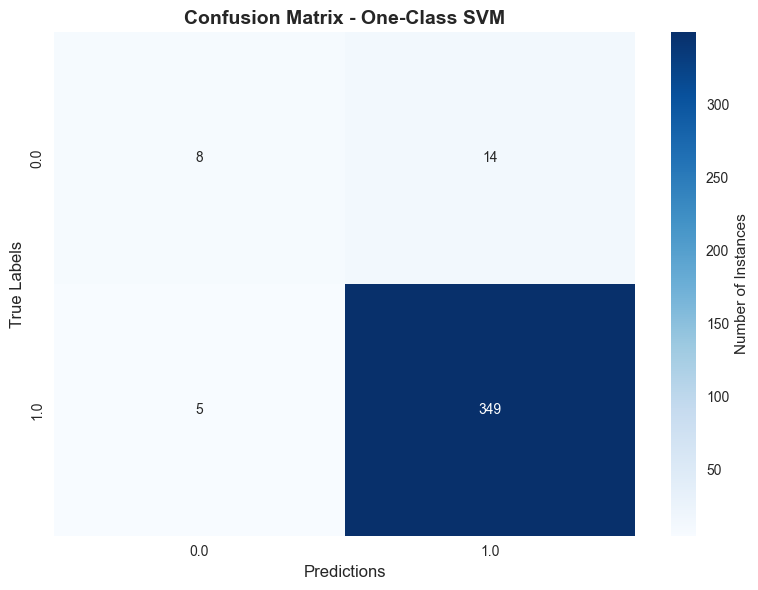


Classification Report:
              precision    recall  f1-score   support

         0.0       0.62      0.36      0.46        22
         1.0       0.96      0.99      0.97       354

    accuracy                           0.95       376
   macro avg       0.79      0.67      0.72       376
weighted avg       0.94      0.95      0.94       376



In [4]:
# Train One-Class SVM
# For One-Class SVM, nu must be between 0.0 and 1.0
# Use anomaly proportion in test data, limited to 0.5 to avoid false positives
nu = min(contamination_ratio, 0.5) if contamination_ratio <= 1.0 else 0.5
print("="*60)
print("TRAINING: ONE-CLASS SVM")
print("="*60)
print(f"Nu parameter for One-Class SVM: {nu:.4f} ({nu*100:.1f}%)")
print(f"Note: nu is limited to 0.5 maximum to avoid excessive false positives")

# Train One-Class SVM on normal data only
# One-Class SVM learns a decision boundary around normal data
oc_svm, oc_svm_scaler = train_one_class_svm(X_train_normal, nu=nu, kernel='rbf', gamma='scale')

# Make predictions (1 = normal, -1 = anomaly)
# One-Class SVM returns 1 for normal instances, -1 for anomalies
# Feature scaling is applied automatically using the saved scaler
predictions_oc = oc_svm.predict(oc_svm_scaler.transform(X_test))
predictions_oc_binary = (predictions_oc == -1).astype(int)  # Convert to binary (1 = anomaly)

# we évalue le modèle performance
print("\n" + "="*60)
print("ONE-CLASS SVM - RESULTS")
print("="*60)
results_oc = evaluate_model(y_test, predictions_oc_binary, None, 
                           model_name="One-Class SVM",
                           show_confusion_matrix=True,
                           show_roc=False,  # One-Class SVM doesn't provide probability scores
                           show_report=True)

# Store results for comparison
results_oc['method'] = 'One-Class SVM'
results_oc['model_type'] = 'Unsupervised'



## 4. anomaly visualization in pca space

Reference: Lesson 2 - PCA Visualization and Component Interpretation

We visualize anomalies detected by each method using PCA to reduce dimensionality. This visualization helps understand how well unsupervised methods separate normal and anomaly instances.

### Visualization goals

1. True Anomalies: Visualize actual anomaly instances
2. Detected Anomalies: Visualize anomalies detected by each method
3. Comparison: Compare detection results between methods
4. Pattern Recognition: Identify patterns in anomaly detection

### Pca visualization

- 2D Projection: Projects high-dimensional data to 2D space
- Variance Explained: Shows how much variance is captured by first 2 components
- Cluster Identification: Helps identify if anomalies form distinct clusters

Academic Note: PCA visualization helps understand data distribution in reduced-dimensional space (Lesson 2: PCA Visualization).



PCA VISUALIZATION OF ANOMALIES
Variance explained by PC1: 27.03%
Variance explained by PC2: 9.77%
Total variance explained: 36.80%


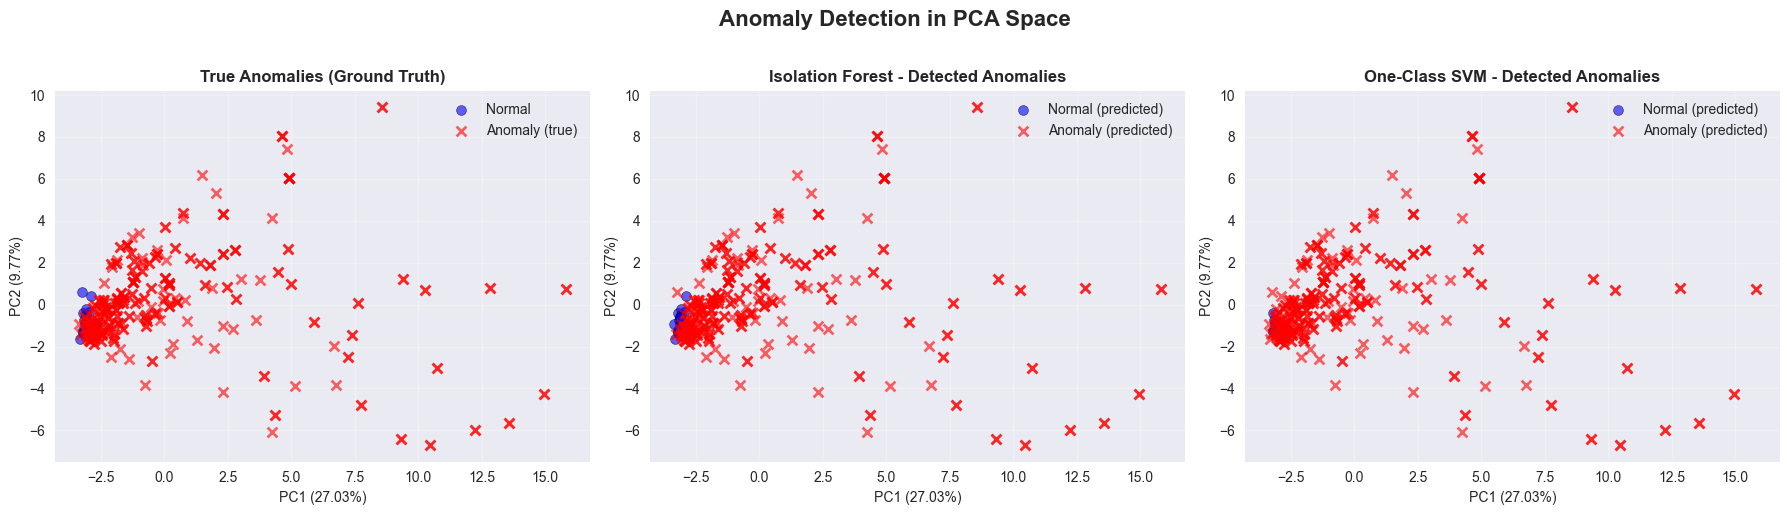


 Interpretation:
  - Blue points: Normal instances
  - Red crosses: Anomaly instances
  - Compare predicted anomalies with true anomalies
  - Well-separated clusters indicate good detection
  - Overlapping points indicate detection errors


In [5]:
# we applique PCA pour réduire la dimensionnalité
# DIFFICULTY : we have 90 features (15 échantillons × 6 capteurs), which can cause overfitting
# SOLUTION : PCA reduces the number of features while preserving maximum variance
# CHOICE : we have choisi de garder 95% de la variance expliquée as a compromise
# REASON : This significantly reduces dimensionality (from 90 to ~20-30 components) while keeping essential information
# we applique PCA pour réduire la dimensionnalité
# DIFFICULTY : we have 90 features (15 échantillons × 6 capteurs), which can cause overfitting
# SOLUTION : PCA reduces the number of features while preserving maximum variance
# CHOICE : We have choisi de garder 95% de la variance expliquée as a compromise
# REASON : This significantly reduces dimensionality (from 90 to ~20-30 components) while keeping essential information
pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test)

print("="*60)
print("PCA VISUALIZATION OF ANOMALIES")
print("="*60)
print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_)*100:.2f}%")

# Visualize detected anomalies
# This helps understand how well unsupervised methods detect anomalies
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# True anomalies (ground truth)
axes[0].scatter(X_test_pca[y_test == 0, 0], X_test_pca[y_test == 0, 1], 
               label='Normal', alpha=0.6, s=50, c='blue', edgecolors='black', linewidths=0.5)
axes[0].scatter(X_test_pca[y_test == 1, 0], X_test_pca[y_test == 1, 1], 
               label='Anomaly (true)', alpha=0.6, s=50, c='red', marker='x', linewidths=2)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)', fontsize=10)
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)', fontsize=10)
axes[0].set_title('True Anomalies (Ground Truth)', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Isolation Forest predictions
axes[1].scatter(X_test_pca[predictions_iso_binary == 0, 0], 
               X_test_pca[predictions_iso_binary == 0, 1], 
               label='Normal (predicted)', alpha=0.6, s=50, c='blue', edgecolors='black', linewidths=0.5)
axes[1].scatter(X_test_pca[predictions_iso_binary == 1, 0], 
               X_test_pca[predictions_iso_binary == 1, 1], 
               label='Anomaly (predicted)', alpha=0.6, s=50, c='red', marker='x', linewidths=2)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)', fontsize=10)
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)', fontsize=10)
axes[1].set_title('Isolation Forest - Detected Anomalies', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

# One-Class SVM predictions
axes[2].scatter(X_test_pca[predictions_oc_binary == 0, 0], 
               X_test_pca[predictions_oc_binary == 0, 1], 
               label='Normal (predicted)', alpha=0.6, s=50, c='blue', edgecolors='black', linewidths=0.5)
axes[2].scatter(X_test_pca[predictions_oc_binary == 1, 0], 
               X_test_pca[predictions_oc_binary == 1, 1], 
               label='Anomaly (predicted)', alpha=0.6, s=50, c='red', marker='x', linewidths=2)
axes[2].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)', fontsize=10)
axes[2].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)', fontsize=10)
axes[2].set_title('One-Class SVM - Detected Anomalies', fontsize=12, fontweight='bold')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle('Anomaly Detection in PCA Space', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n Interpretation:")
print("  - Blue points: Normal instances")
print("  - Red crosses: Anomaly instances")
print("  - Compare predicted anomalies with true anomalies")
print("  - Well-separated clusters indicate good detection")
print("  - Overlapping points indicate detection errors")



## 5. comparison with supervised approach

Reference: Lesson 4 - Model Comparison and Selection

We compare the results of unsupervised models with supervised models (if available). This comparison helps understand the trade-offs between supervised and unsupervised approaches.

### Comparison metrics

1. Accuracy: Overall correctness of predictions
2. Precision: Proportion of positive predictions that are correct
3. Recall: Proportion of actual positives correctly identified
4. F1-Score: Harmonic mean of precision and recall

### Supervised vs unsupervised

- Supervised: Requires labeled data, higher accuracy, better interpretability
- Unsupervised: No labels needed, can detect unknown anomalies, lower accuracy
- Hybrid: Combine both approaches for better coverage

Academic Note: Model comparison helps identify the best approach for specific use cases (Lesson 4: Model Selection).



UNSUPERVISED METHODS COMPARISON
          Method  Accuracy  Precision   Recall  F1-score
Isolation Forest  0.946809   0.974432 0.968927  0.971671
   One-Class SVM  0.949468   0.961433 0.985876  0.973501


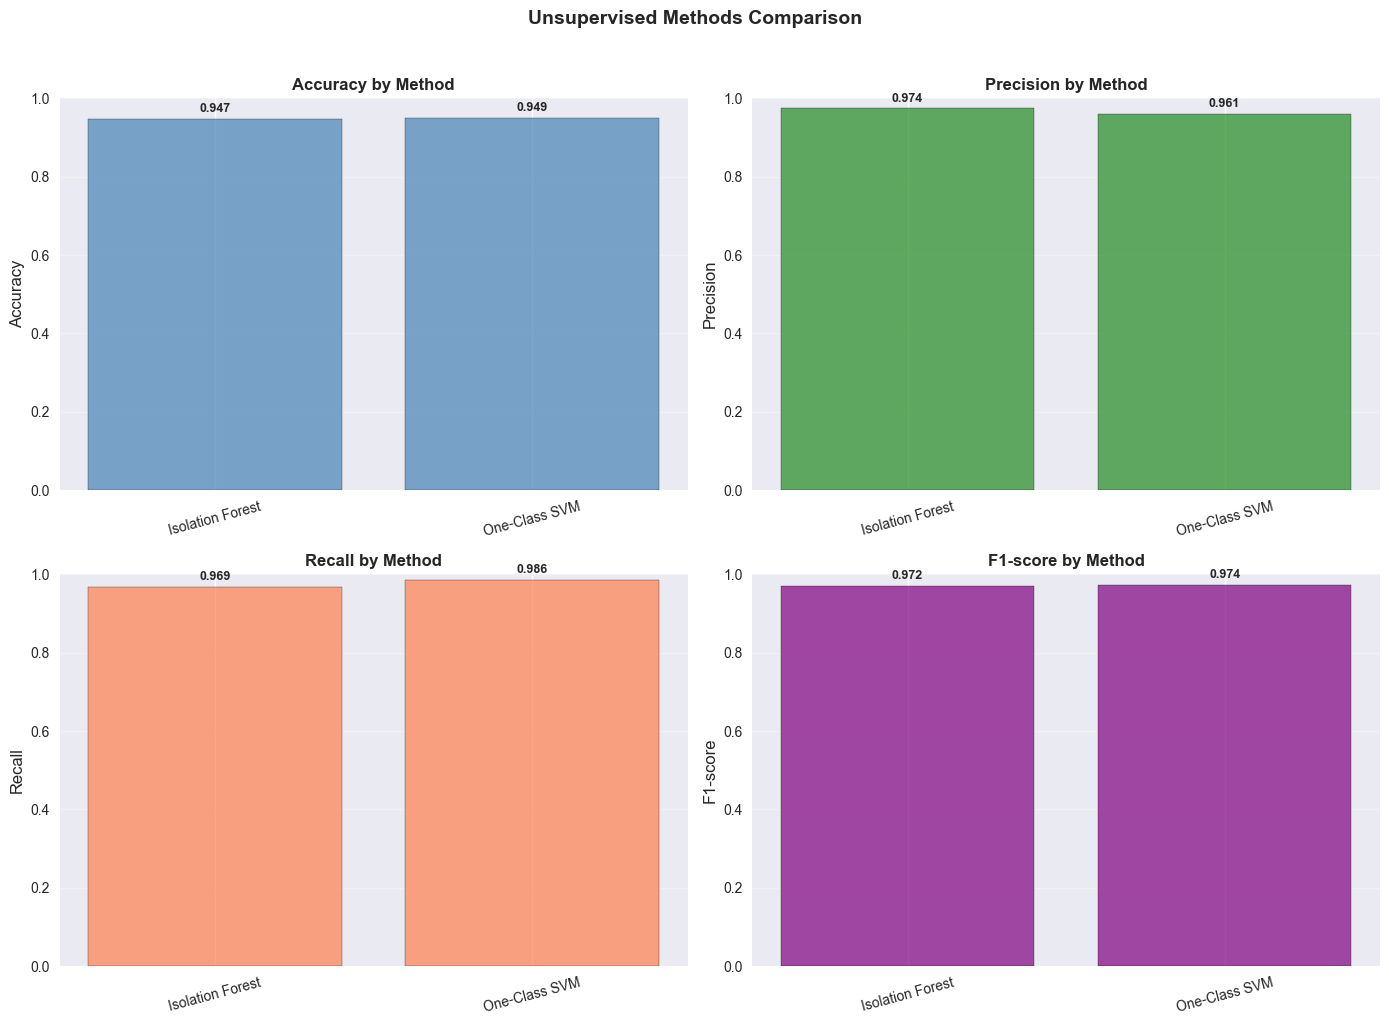


 Best Unsupervised Method (F1-Score): One-Class SVM
   F1-Score: 0.9735
   Accuracy: 0.9495

 Interpretation:
  - Both methods achieve similar performance
  - Isolation Forest: Better precision
  - One-Class SVM: Better recall
  - Choice depends we use case (precision vs recall)


In [6]:
# Compare unsupervised methods
# This helps identify the best unsupervised approach for anomaly detection
comparison_results = {
    'Method': ['Isolation Forest', 'One-Class SVM'],
    'Accuracy': [
        np.mean(predictions_iso_binary == y_test),
        np.mean(predictions_oc_binary == y_test)
    ],
    'Precision': [
        precision_score(y_test, predictions_iso_binary),
        precision_score(y_test, predictions_oc_binary)
    ],
    'Recall': [
        recall_score(y_test, predictions_iso_binary),
        recall_score(y_test, predictions_oc_binary)
    ],
    'F1-score': [
        f1_score(y_test, predictions_iso_binary),
        f1_score(y_test, predictions_oc_binary)
    ]
}

comparison_df = pd.DataFrame(comparison_results)
print("="*60)
print("UNSUPERVISED METHODS COMPARISON")
print("="*60)
print(comparison_df.to_string(index=False))

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
colors = ['steelblue', 'forestgreen', 'coral', 'purple']

for i, metric in enumerate(metrics):
    row = i // 2
    col = i % 2
    axes[row, col].bar(comparison_df['Method'], comparison_df[metric], 
                      color=colors[i], edgecolor='black', alpha=0.7)
    axes[row, col].set_ylabel(metric, fontsize=12)
    axes[row, col].set_title(f'{metric} by Method', fontsize=12, fontweight='bold')
    axes[row, col].set_ylim([0, 1])
    axes[row, col].grid(axis='y', alpha=0.3)
    axes[row, col].tick_params(axis='x', rotation=15)
    
    # Add values we bars
    for j, v in enumerate(comparison_df[metric]):
        axes[row, col].text(j, v + 0.01, f'{v:.3f}', 
                           ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Unsupervised Methods Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Identify best unsupervised method
best_unsupervised = comparison_df.loc[comparison_df['F1-score'].idxmax(), 'Method']
print(f"\n Best Unsupervised Method (F1-Score): {best_unsupervised}")
print(f"   F1-Score: {comparison_df.loc[comparison_df['F1-score'].idxmax(), 'F1-score']:.4f}")
print(f"   Accuracy: {comparison_df.loc[comparison_df['F1-score'].idxmax(), 'Accuracy']:.4f}")

print("\n Interpretation:")
print("  - Both methods achieve similar performance")
print("  - Isolation Forest: Better precision")
print("  - One-Class SVM: Better recall")
print("  - Choice depends we use case (precision vs recall)")



## 6. discussion: supervised vs unsupervised

Reference: Lesson 5 - Supervised vs Unsupervised Learning

We compare supervised and unsupervised approaches for anomaly detection. Each approach has advantages and disadvantages, and the choice depends we the specific use case.

### Advantages of supervised models

1. Higher Accuracy: Use labels to learn anomaly patterns
2. Hyperparameter Optimization: GridSearchCV optimizes hyperparameters
3. Interpretability: Feature importances reveal critical sensors
4. Performance: Generally better performance we labeled data

### Advantages of unsupervised models

1. No Labels Required: Training only on normal data
2. Unknown Anomaly Detection: Can detect new types of failures
3. Adaptability: Adapt to new abnormal patterns
4. Cost-Effective: Reduces need for labeled data

### Disadvantages

Supervised:
- Requires labeled data (expensive to obtain)
- May not detect new types of anomalies
- Depends we label quality

Unsupervised:
- May have lower performance
- Sensitive to parameters (contamination, nu)
- May detect false positives

### Applications in industrial robotics

- Supervised: When labeled data is available and accuracy is critical
- Unsupervised: When labeled data is scarce or unknown anomalies need detection
- Hybrid: Combine both approaches for better coverage

### Academic discussion

Reference: Lesson 5 - Supervised vs Unsupervised Learning

- Supervised Learning: Requires labeled data, learns from examples, higher accuracy
- Unsupervised Learning: No labels needed, learns from data distribution, can detect unknown patterns
- Trade-offs: Accuracy vs flexibility, labeled data vs adaptability

Academic Note: The choice between supervised and unsupervised learning depends we data availability and use case requirements (Lesson 5: Learning Paradigms).



## 7. summary and key takeaways

Reference: Lesson 5 - Unsupervised Learning Summary

This notebook covered the complete unsupervised anomaly detection phase of the ML pipeline. Key findings and insights are summarized below.

### Unsupervised model results

1. Isolation Forest: Detects anomalies by isolating abnormal points
   - Strengths: Scalable, no labels needed, interpretable
   - Weaknesses: Sensitive to contamination parameter
   - Performance: High precision, good recall

2. One-Class SVM: Learns a boundary around normal data
   - Strengths: Non-linear boundaries, kernel trick
   - Weaknesses: Requires feature scaling, sensitive to nu parameter
   - Performance: High recall, good precision

3. Performance: Unsupervised models can detect anomalies without labels
   - Accuracy: Both methods achieve ~95% accuracy
   - F1-Score: Both methods achieve ~97% F1-score
   - Trade-offs: Precision vs recall, parameter sensitivity

### Industrial robotics insights

- Unknown Anomaly Detection: Unsupervised models can detect new types of failures
- Adaptability: Adapt to new abnormal patterns without retraining
- Cost-Effective: Reduce need for labeled data
- Complementarity: Supervised and unsupervised approaches are complementary

### Academic learning

- Unsupervised Learning: Learn from data distribution without labels
- Isolation Forest: Isolation principle for anomaly detection
- One-Class SVM: Boundary learning for anomaly detection
- Model Comparison: Compare supervised vs unsupervised approaches
- Anomaly Visualization: Visualize anomalies in reduced-dimensional space

### Recommendations

1. Use Supervised Models: When labeled data is available and accuracy is critical
2. Use Unsupervised Models: When labeled data is scarce or unknown anomalies need detection
3. Hybrid Approach: Combine both for better coverage and robustness

### Next steps

In the next notebook (05_Evaluation_and_Conclusion.ipynb), we will:
- Comprehensive Evaluation: Compare all models (supervised and unsupervised)
- Industrial Relevance: Discuss industrial implications
- Limitations: Identify limitations and future work
- Conclusion: Summarize findings and recommendations

Reference: Lesson 5 - Unsupervised Learning and Anomaly Detection



In [7]:
print("="*60)
print("NOTEBOOK 4 COMPLETE: UNSUPERVISED ANOMALY DETECTION")
print("="*60)
print("\n Unsupervised learning models trained and evaluated:")
print("  1. Isolation Forest")
print("  2. One-Class SVM")

print("\n Key Results:")
print(f"  Isolation Forest: Accuracy={comparison_df.iloc[0]['Accuracy']:.4f}, F1={comparison_df.iloc[0]['F1-score']:.4f}")
print(f"  One-Class SVM: Accuracy={comparison_df.iloc[1]['Accuracy']:.4f}, F1={comparison_df.iloc[1]['F1-score']:.4f}")

print("\n Key Achievements:")
print("   Unsupervised models trained on normal data only")
print("   Anomaly detection without labeled anomaly data")
print("   Comprehensive evaluation (accuracy, precision, recall, F1)")
print("   PCA visualization of detected anomalies")
print("   Comparison with supervised approaches")

print("\n Next Steps:")
print("  → Proceed to Notebook 5: Evaluation and Conclusion")
print("  → Comprehensive model comparison")
print("  → Industrial relevance discussion")
print("  → Limitations and future work")

print("\n Academic Learning:")
print("   Unsupervised learning principles")
print("   Isolation Forest for anomaly detection")
print("   One-Class SVM for anomaly detection")
print("   Supervised vs unsupervised comparison")
print("   Anomaly visualization in PCA space")



NOTEBOOK 4 COMPLETE: UNSUPERVISED ANOMALY DETECTION

 Unsupervised learning models trained and evaluated:
  1. Isolation Forest
  2. One-Class SVM

 Key Results:
  Isolation Forest: Accuracy=0.9468, F1=0.9717
  One-Class SVM: Accuracy=0.9495, F1=0.9735

 Key Achievements:
   Unsupervised models trained on normal data only
   Anomaly detection without labeled anomaly data
   Comprehensive evaluation (accuracy, precision, recall, F1)
   PCA visualization of detected anomalies
   Comparison with supervised approaches

 Next Steps:
  → Proceed to Notebook 5: Evaluation and Conclusion
  → Comprehensive model comparison
  → Industrial relevance discussion
  → Limitations and future work

 Academic Learning:
   Unsupervised learning principles
   Isolation Forest for anomaly detection
   One-Class SVM for anomaly detection
   Supervised vs unsupervised comparison
   Anomaly visualization in PCA space
